# Building a neural network from scratch with NumPy
This notebook documents the full process of implementing a basic feedforward neural network to classify handwritten digits using the MNIST dataset.

## 1. Introduction
### Why build from scratch?
Modern machine learning frameworks like PyTorch and Tensorflow are incredibly powerful - but they abstract away almost all of the core mathematical operations. While this is ideal for productivity, since neural networks can be built in a few lines of code, it can lead to a shallow understanding of what's actually happening under the hood.

I find I need to take complex ideas apart into their smallest building blocks and rebuild them myself before I truly understand why they work, and can confidently apply that knowledge to new problems. This project is that process: my attempt to lift the hood on neural networks by implementing one from scratch using only NumPy. The goal is simple: if I can't build it myself, then I don't fully understand it.

### Why this format?
Jupyter notebooks allow me to weave together markdown, LaTeX and Python into a singular narrative. This flexibility turns the project into more than just code - it becomes a computational notebook in the truest sense:
- Markdown captures the reasoning and context
- LaTeX allows accurate typesetting of complex mathematical expressions
- Python turns theory into executable code.

This particular format encourages deep thinking and makes the learning process visible - not just the end result. It also aligns with the traditions of science and mathematics, where understanding is often built through annotated derivations, not just final answers. 

### Overview of Architecture
The most basic versions of neural networks are known as multi-layer perceptrons, or MLPs. 

We will build a MLP with a single hidden layer, as understanding MLPs is somewhat of a pre-requisite to understanding more modern varients of neural networks.
There will be 784 nodes in the input layer, a single hidden layer consisting of 32 nodes (because honestly, that's a nice number that we can easily visualise to see what the network is learning), and an output layer of 10 nodes - one corresponding to each of the 10 possible classes the digits belong to. 

In [ ]:
$ z= w_1 x_1+w_2 x_2+w_n x_n =\textbf{X}^T \textbf{W} $

## 2. Load and Preprocess MNIST dataset
Yes, I know this comes from Keras, but honestly, this was the fastest way to get the data as a numpy array. The original data is in some obscure binary format. Each image is a 28x28 numpy array. 
**Training set:** contains 60,000 images. 
**Test set:** contains 10,000 images.

Array: [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253

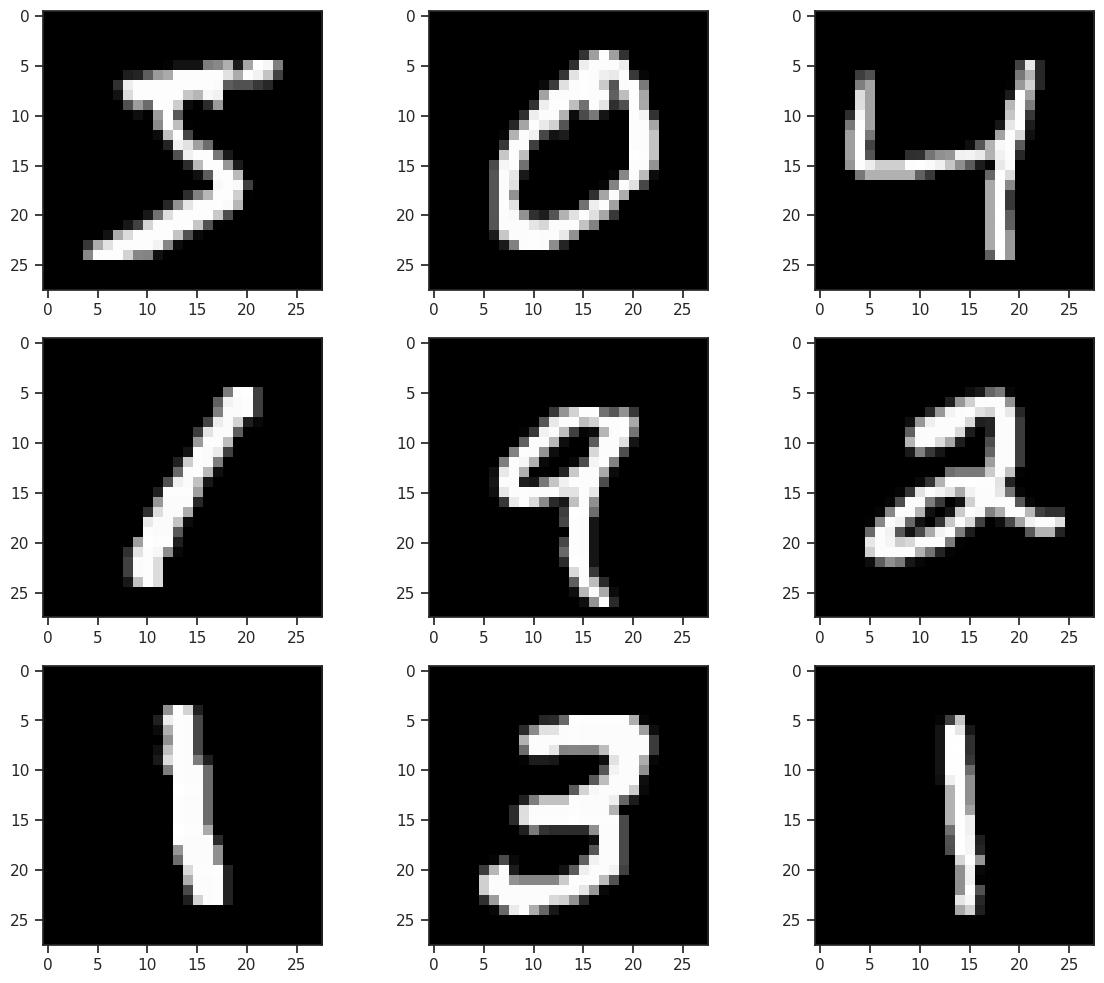

In [19]:
# Import necessary packages
import numpy as np 
import pandas as pd
from keras.datasets import mnist
import matplotlib.pyplot as plt 
import seaborn as sns

# Control global appearance of figures etc. 
sns.set_theme(context="notebook", style="ticks", palette="viridis")

# Import and visualise the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f'Array: {X_train[0]}')
print(f'Training Label: {y_train[0]}')

#Plot the first 9 images in the data set
fig, ax = plt.subplots(3,3) 
fig.set_size_inches(12, 10)
k = 0
for i in range(3):
    for j in range(3):
        ax[i,j].imshow(X_train[k].reshape(28, 28), cmap="gray")
        k += 1
plt.tight_layout()


Firstly, we need to normalise the dataset. Currently, the arrays for the images are between 0 (completely black pixel) and 255 (completely white pixel). However, neural networks really, _really_ like inputs to be between 0 and 1. Easiest way to do this: simply divide every value in the array by 255. 

Next, squash the array for each image to a 1-dimensional vector. These 1D vectors are much faster to calculate than a 28x28 matrix. This will give a 1D vector of 784 columns (28x28 = 784) for each image. The training set should then be an array of 60000 rows and 784 columns, and the  test set 1000 rows and also 784 columns. The labels are already a 1D array and do not need reshaping here. 

In [ ]:
# Normalise the data
X_train = X_train/255
X_test = X_test/255

print(f'Normalised Array: {X_train[0]}')

# Flatten X_train and X_test to 1 dimension, then confirm we have done so using .shape method
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f'Shape of X_train: {X_train.shape}')
print(f'Shape of X_test: {X_test.shape}')

#### 📚 Side Quest: How might we reshape the array using np.ndarray.flatten?
TODO: what does np.ndarray.flatten actually do? 

x.flatten() flattens each individual sample into a 1D array.
Wrapping with np.array([...]) reconstructs a 2D array: shape becomes (num_samples, features_per_sample)

In [ ]:
X_test = np.array([x.flatten() for x in X_test])
print(f'Shape of X_test: {X_test.shape}')

Finally, One-hot encode the labels, and convert them from ["6, 9, 4, 3"] to strings of ones and zeros representing the number. **Remember** Python indexes from zero, not one. So the array is 0-9, not 1-9, and then 0. 

In [ ]:
# One Hot encode the image labels
# Code shamelessly borrowed from: https://stackoverflow.com/questions/29831489/convert-array-of-indices-to-one-hot-encoded-array-in-numpy

n_values = np.max(y_train) + 1
y_train_encoded = np.eye(n_values)[y_train]
n_values = np.max(y_test) + 1
y_test_encoded = np.eye(n_values)[y_test]

# Select a random image from the training and test set and print the original label and encoded label to confirm this has worked. 
print(f'Original label: {y_train[42]}\nEncoded label: {y_train_encoded[42]}')
print(f'Original label: {y_test[42]}\nEncoded label: {y_test_encoded[42]}')

Now, each image is a 784-dimensional vector, normalised so each value within the vector is between 0 and 1. Each image label has been One-hot encoded so that it is a 10-dimensional vector and we have a test and train set. The data is now ready to be passed through the neural network.

## 3. Define Core Components of the Neural Network
There are many frequently used components in neural networks. These include: dense (fully connected) layers, a number of activation functions like reLU, Sigmoid and Softmax, loss functions and a number of different optimisation methods like Stochastic Gradient Descent (SDG) and Adam.

### Dense (fully connected) layers
When all the neurons in a layer are connected to every neuron in the previous layer _i.e.,_ the input neurons, this is called a dense or fully connected layer. 

### Activation functions (reLU, Sigmoid, Softmax)
#### Why do we need activation functions?
Activation functions are necessary, because if we chain several linear transformations together, all you get out is another linear transformation. Essentially, without the nonlinearity introduced between layers by the activation functions, then even a stack of 100 layers is effecively equivalent to a single layer, and you can't solve very complex problems with that. 

Sigmoid - very negative inputs end up close to zero, positive inputs are close to 1. 

ReLU - Rectified linear unit. This function is not differentiable at z=0, as the gradient changes abruptly, which can make Gradient Descent bounce around. However, it is fast to compute, considered to be easier to train than Sigmoid functions, and therefore learn faster. So this is often the default activation function used within neural networks.  

tanh - Hyperbolic tan function. Just like the sigmoid function, this function is also s-shaped, continuous and differentiable, but it's output ranges from -1 to 1. This range tends to make each layers output more or less centered around 0 at the beginning of training, which often helps speed up convergence. 

Softmax - Useful in multiclass classification problems as it ensures that all the estimated probabilities are between 0 and 1 and that they all add up to 1, which is needed if the classes are exclusive _i.e.,_ that an input can only belong to a single class. 

In [ ]:
$ \textbf{Activation functions}

\sigma(x) = 1/1+e^-x 

ReLU(x) = max(0,x) 

softmax(x_{i}) = \frac{e^{x_{i}-max(x)}}{\sum_{j} e^{x_{j}-max(x)}}

tanh(x)= 2\sigma(2x)-1 $

### Loss function (cross-entropy)
Cross entropy loss (also called the log loss) is used here, because we are predicting a probability distribution. 
### Optimisation (Adam, SDG)

### Accuracy metric

In [ ]:
# Define activation functions in python

def sigmoid(x):
    """Sigmoid activation function. Maps input values to a range between 0 and 1.

    Args:
        x (np.ndarray): Input array or scalar.

    Returns:
        np.ndarray: Output after applying the sigmoid function element-wise.
        """
    return 1/(1 + np.exp(-x))

def relu(x):
    """ReLU (Rectified Linear Unit) activation function. Applies the function f(x) = max(0, x) element-wise.

    Args:
        x (np.ndarray): Input array or scalar.

    Returns:
        np.ndarray: Output after applying ReLU element-wise.
    """
    return np.maximum(0,x)

def softmax(x):
    """ Numerically stable softmax activation function. Converts logits to probabilities by exponentiating input values
        after subtracting the maximum to improve numerical stability.

        Args:
            x (np.ndarray): Input array of shape (batch_size, num_classes)
                            or any shape where softmax is applied along the last axis.

        Returns:
            np.ndarray: Probability distribution with the same shape as input,
                        where values sum to 1 along the softmax axis.
        """
    exps = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return exps / np.sum(exps, axis=-1, keepdims=True)

#### 📚 Side Quest: Plot Activation functions so we can see what they look like.
Plotting activation functions serves two purposes: allows us to develop a feel for how the function behaves across a range of input values, it makes it immediately clear why reLU is better for deep networks (it avoids saturation) and how sigmoid squashifies the values between 0 and 1; it also enables us to verify we've implemented the functions correctly in numpy. This is useful because we have none of debugging tools in Tensorflow/ Pytorch at our disposal. 

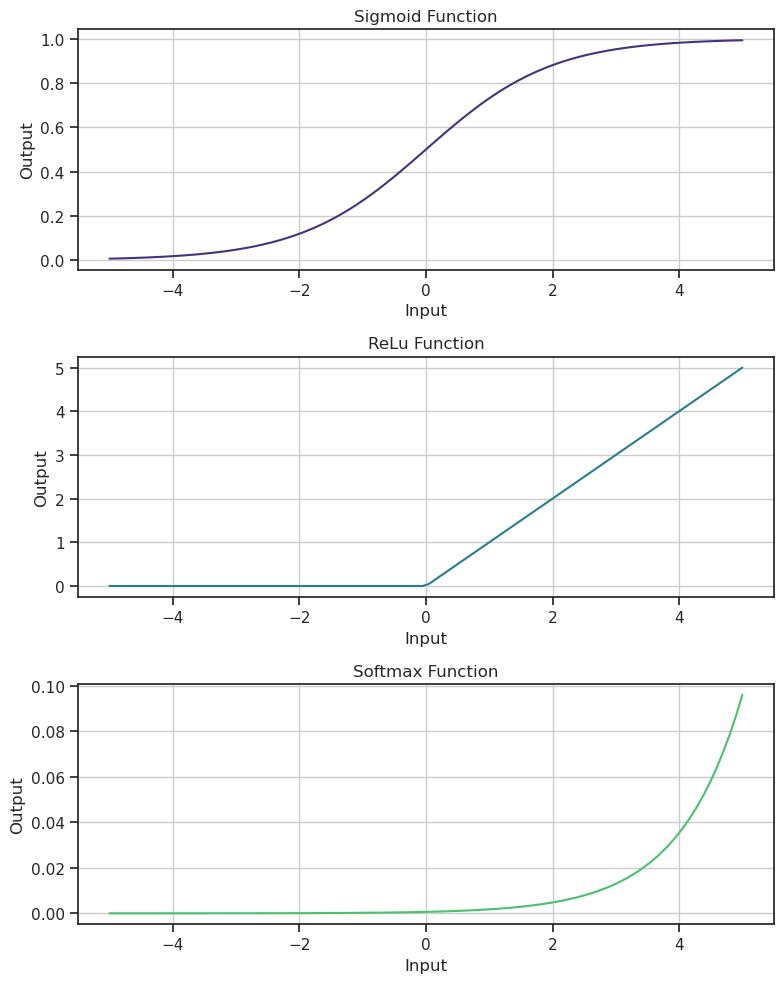

In [33]:
# Generate input values
x = np.linspace(-5, 5, 100)

# Compute activation values
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_softmax = softmax(x)

# Create the plot
fig, axes = plt.subplots(3,1, figsize=(8,10))

axes[0].plot(x, y_sigmoid, color=sns.color_palette("viridis")[0])
axes[0].set_title("Sigmoid Function")
axes[0].set_xlabel("Input")
axes[0].set_ylabel("Output")
axes[0].grid(True)

axes[1].plot(x, y_relu, color=sns.color_palette("viridis")[2])
axes[1].set_title("ReLu Function")
axes[1].set_xlabel("Input")
axes[1].set_ylabel("Output")
axes[1].grid(True)

axes[2].plot(x, y_softmax, color=sns.color_palette("viridis")[4])
axes[2].set_title("Softmax Function")
axes[2].set_xlabel("Input")
axes[2].set_ylabel("Output")
axes[2].grid(True)

# Formatting
plt.tight_layout()
plt.show()

#### 📚 Side Quest: What is the vanishing gradient problem?

#### 📚 Sidequest: What is the difference between Softmax and safe Softmax?
Why might we use one over the other?

## 4. Forward Propagation
- show data moving through layers
- visualise activations


## 5. Backward Propagation
Backwards propagation is how a neural network learns. 

- chain rule underpins back prop
- compute gradients manually
- show how weights update

In [ ]:
# This is how a network learns
# Cost function is how we tell the network that it's wrong. Add up the squares of the differences between the output activations, and the value that the network should have given, and then training will seek to minimise this function. 
# Show how weights and biases update
# learning rate is a hyperparameter. 

## 6. Training Loop
- Track accuracy, loss
- plot learning curve

## 7. Evaluation
- Test set accuracy
- confusion matrix

In [ ]:
#accuracy = number correct/ total images x100
# confusion matrix
# visualise some of the images that the network gets wrong. 

## 8. Wrap Up
- Refactor code to modules
- Comparison with Pytorch/ Tensorflow